# Bolero: does depth-based layered reconstruction preserve the cues a classifier relies on?

**System under test.** ResNet-50 (`microsoft/resnet-50`, ImageNet-1k) as the deployed
recognizer, with a monocular-depth reconstruction front-end (Depth-Anything-V2-Small,
the MiDaS-lineage relative-depth estimator of Birkl et al.) applied as preprocessing.

**Question.** Preprocessing that is *visually* faithful is often assumed to be
*semantically* faithful. We measure that assumption directly: on 3,925 Imagenette
validation images, what does depth-layer reconstruction cost in accuracy, in
prediction stability, and in calibration — and is the damage uniform across classes?

**Why it matters for deployment.** Depth-layer preprocessing is used ahead of
recognition in AR compositing, novel-view synthesis and re-lighting pipelines. If it
silently degrades some classes far more than others, and confidence does not fall to
match, a deployer gets a quiet accuracy loss that no aggregate monitor will catch.

---

### What in here is reproducible, and what is not

| Part | Status |
|---|---|
| The audit (§1–§5) | **Fully reproducible** from `bolero_evidence.csv`, which is in this repo. |
| Depth-side pipeline (§6) | **Reproducible** — runs Depth-Anything-V2-Small locally on the Imagenette images. |
| The reconstruction step that produced `bolero_prediction` | **Not in this repo.** See §7. |

`01_bolero.ipynb` is kept as the original exploratory record. It does not run on a
fresh kernel (hard-coded `F:\` paths, two missing imports, and a final cell referencing
six undefined variables); this notebook supersedes it.

In [1]:
# ============================================================
# §0  Configuration
# ============================================================

from pathlib import Path
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# ---- Repo root: walk up from cwd until we find the evidence file ----

def find_repo_root(marker: str = "bolero_evidence.csv") -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate {marker} in {here} or any parent. "
        "Run this notebook from inside the repository."
    )

REPO = find_repo_root()
EVIDENCE_CSV = REPO / "bolero_evidence.csv"

RESULTS = REPO / "results"
FIGURES = RESULTS / "figures"
for d in (RESULTS, FIGURES):
    d.mkdir(parents=True, exist_ok=True)

# ---- Imagenette images: outside the repo, so allow an override ----

def find_imagenette_root() -> Path | None:
    env = os.environ.get("IMAGENETTE_ROOT")
    candidates = []
    if env:
        candidates.append(Path(env))
    candidates += [
        REPO.parent / "clip_corruption_calibration" / "data" / "imagenette2-160",
        REPO / "data" / "imagenette2-160",
    ]
    for c in candidates:
        if (c / "val").is_dir():
            return c.resolve()
    return None

IMAGENETTE_ROOT = find_imagenette_root()

RECOGNITION_MODEL = "microsoft/resnet-50"
DEPTH_MODEL = "depth-anything/Depth-Anything-V2-Small-hf"

# ---- Plot style: light surface, recessive grid, ink-colored text ----
# Categorical slots 1 and 2 of the validated reference palette.
# Validated all-pairs, light mode: CVD dE 24.7, normal-vision dE 33.6, both >= 3:1.

SURFACE      = "#fcfcfb"
INK_PRIMARY  = "#0b0b0b"
INK_SECOND   = "#52514e"
INK_MUTED    = "#8a8983"
GRID         = "#e6e5e1"

SERIES_ORIGINAL = "#2a78d6"   # slot 1, blue
SERIES_BOLERO   = "#eb6834"   # slot 2, orange
DIVERGE_POS     = "#2a78d6"   # gain
DIVERGE_NEG     = "#e34948"   # loss

mpl.rcParams.update({
    "figure.facecolor":  SURFACE,
    "axes.facecolor":    SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   INK_SECOND,
    "axes.titlecolor":   INK_PRIMARY,
    "axes.titleweight":  "bold",
    "axes.titlesize":    12,
    "axes.titlelocation": "left",
    "axes.titlepad":     12,
    "axes.labelsize":    10,
    "axes.grid":         True,
    "axes.axisbelow":    True,
    "grid.color":        GRID,
    "grid.linewidth":    0.8,
    "xtick.color":       INK_SECOND,
    "ytick.color":       INK_SECOND,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.frameon":    False,
    "legend.fontsize":   9,
    "lines.linewidth":   2.0,
    "font.size":         10,
    "figure.dpi":        110,
    "savefig.dpi":       200,
    "savefig.bbox":      "tight",
})

def strip_axes(ax, keep=("left", "bottom")):
    """Recessive frame: drop spines we do not need."""
    for side, spine in ax.spines.items():
        spine.set_visible(side in keep)

print(f"repo            : {REPO}")
print(f"evidence        : {EVIDENCE_CSV.name}  ({EVIDENCE_CSV.stat().st_size/1e6:.1f} MB)")
print(f"imagenette root : {IMAGENETTE_ROOT if IMAGENETTE_ROOT else 'NOT FOUND (set IMAGENETTE_ROOT)'}")
print(f"results         : {RESULTS}")

repo            : /Users/venkat/Desktop/Masters/ASU/Classes/ODM/CSE_598_ODL_project
evidence        : bolero_evidence.csv  (2.8 MB)
imagenette root : /Users/venkat/Desktop/Masters/ASU/Classes/ODM/clip_corruption_calibration/data/imagenette2-160
results         : /Users/venkat/Desktop/Masters/ASU/Classes/ODM/CSE_598_ODL_project/results


## §1 The label mapping, verified against the model's own config

Imagenette identifies classes by WordNet id (`n03028079`). ResNet-50 emits an
ImageNet-1k *index* (`497`). Every correctness claim in this study depends on that
mapping, so we do not hard-code it on trust — we assert it against the deployed
model's `id2label`.

This matters more than it looks. The naive shortcut is to derive the mapping from
each class's *most frequent* prediction. That is wrong for exactly one class here:
**church** is most often predicted `monastery` (663), which is a genuine model
confusion, not a mapping artifact. Deriving from the mode would silently define the
error away.

In [2]:
# ============================================================
# §1  wnid -> ImageNet-1k index, asserted against id2label
# ============================================================

# ImageNet-1k indices follow ascending wnid order; these are the 10 Imagenette classes.
IMAGENETTE_INDEX = {
    "n01440764": 0,    # tench
    "n02102040": 217,  # English springer
    "n02979186": 482,  # cassette player
    "n03000684": 491,  # chain saw
    "n03028079": 497,  # church
    "n03394916": 566,  # French horn
    "n03417042": 569,  # garbage truck
    "n03425413": 571,  # gas pump
    "n03445777": 574,  # golf ball
    "n03888257": 701,  # parachute
}

EXPECTED_LABEL_PREFIX = {
    0: "tench", 217: "English springer", 482: "cassette player",
    491: "chain saw", 497: "church", 566: "French horn",
    569: "garbage truck", 571: "gas pump", 574: "golf ball",
    701: "parachute",
}

id2label = None
try:
    from transformers import AutoConfig
    cfg = AutoConfig.from_pretrained(RECOGNITION_MODEL)
    id2label = {int(k): v for k, v in cfg.id2label.items()}
except Exception as exc:                                    # offline / no model cache
    warnings.warn(f"Could not load {RECOGNITION_MODEL} config ({exc}). "
                  "Skipping the mapping assertion.")

if id2label is not None:
    assert len(id2label) == 1000, f"expected 1000 labels, got {len(id2label)}"
    mismatches = [
        (idx, EXPECTED_LABEL_PREFIX[idx], id2label[idx])
        for idx in EXPECTED_LABEL_PREFIX
        if not id2label[idx].startswith(EXPECTED_LABEL_PREFIX[idx])
    ]
    assert not mismatches, f"wnid->index mapping disagrees with model config: {mismatches}"

    print(f"Verified against {RECOGNITION_MODEL} id2label ({len(id2label)} classes)\n")
    for wnid, idx in IMAGENETTE_INDEX.items():
        print(f"  {wnid}  ->  {idx:4d}  {id2label[idx]}")
    print("\nAll 10 indices match the deployed model's label table.")
else:
    print("Mapping assertion skipped (model config unavailable).")

/Users/venkat/Desktop/Masters/ASU/Classes/ODM/clip_corruption_calibration/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Verified against microsoft/resnet-50 id2label (1000 classes)

  n01440764  ->     0  tench, Tinca tinca
  n02102040  ->   217  English springer, English springer spaniel
  n02979186  ->   482  cassette player
  n03000684  ->   491  chain saw, chainsaw
  n03028079  ->   497  church, church building
  n03394916  ->   566  French horn, horn
  n03417042  ->   569  garbage truck, dustcart
  n03425413  ->   571  gas pump, gasoline pump, petrol pump, island dispenser
  n03445777  ->   574  golf ball
  n03888257  ->   701  parachute, chute

All 10 indices match the deployed model's label table.


In [3]:
# ============================================================
# §2  Load the evidence, remap image paths to this machine
# ============================================================

evidence = pd.read_csv(EVIDENCE_CSV)

print(f"rows x cols : {evidence.shape[0]:,} x {evidence.shape[1]}")
print(f"nulls       : {int(evidence.isna().sum().sum())}")
print(f"classes     : {evidence['class_id'].nunique()}")

# ---- image_path was recorded on Windows; rebase onto the local dataset ----

def rebase_image_path(recorded: str) -> Path | None:
    """Rebase a recorded path onto IMAGENETTE_ROOT by its 'imagenette2-160/...' tail."""
    if IMAGENETTE_ROOT is None:
        return None
    parts = recorded.replace("\\", "/").split("imagenette2-160/")
    if len(parts) != 2:
        return None
    return IMAGENETTE_ROOT / parts[1]

evidence["local_image_path"] = evidence["image_path"].map(rebase_image_path)

if IMAGENETTE_ROOT is not None:
    resolved = evidence["local_image_path"].map(lambda p: p is not None and p.exists())
    print(f"\nimages resolved locally : {int(resolved.sum()):,} / {len(evidence):,}")
    if not resolved.all():
        print("  unresolved sample:")
        for p in evidence.loc[~resolved, "image_path"].head(3):
            print("   ", p)
else:
    print("\nimages resolved locally : skipped (IMAGENETTE_ROOT not set)")

# ---- The other four artifact columns are Windows-only; flag and drop ----

ARTIFACT_COLS = ["depth_path", "boundary_path", "thermal_path", "reconstruction_path"]
print("\nArtifact columns (depth/boundary/thermal/reconstruction .npy and .png):")
print("  recorded under F:\\DeepLearningTest\\bolero_repo\\ — not present locally.")
print("  The audit below does not depend on them; §6 regenerates the depth side.")

rows x cols : 3,925 x 20
nulls       : 0
classes     : 10

images resolved locally : 3,925 / 3,925

Artifact columns (depth/boundary/thermal/reconstruction .npy and .png):
  recorded under F:\DeepLearningTest\bolero_repo\ — not present locally.
  The audit below does not depend on them; §6 regenerates the depth side.


## §3 The defect in the shipped correctness columns

`bolero_evidence.csv` carries `original_correct` and `bolero_correct`. **Both are
wrong**, and wrong in a way that is easy to miss because the headline number it
produces (~9.5%) is low but not absurd.

The script that wrote the file compared the *wnid* against the predicted *index*.
That comparison can only ever succeed for `n01440764` → index `0`, so tench is the
only class that ever scores. The other nine are zero by construction.

The signature of this bug is asymmetry: many rows recorded wrong that are actually
right, and **none** in the other direction. We check for exactly that below.

In [4]:
# ============================================================
# §3  Recompute correctness; quantify the defect
# ============================================================

true_index = evidence["class_id"].map(IMAGENETTE_INDEX)
assert true_index.notna().all(), "unmapped class_id present"

evidence["true_index"]        = true_index.astype(int)
evidence["original_correct_fixed"] = evidence["original_prediction_id"] == evidence["true_index"]
evidence["bolero_correct_fixed"]   = evidence["bolero_prediction_id"]   == evidence["true_index"]

rec_o = evidence["original_correct"].astype(bool)
rec_b = evidence["bolero_correct"].astype(bool)
fix_o = evidence["original_correct_fixed"]
fix_b = evidence["bolero_correct_fixed"]

print("Which classes ever score under the shipped columns?")
print(evidence.loc[rec_o, "class_name"].value_counts().to_string())

false_neg = int((fix_o & ~rec_o).sum())
false_pos = int((~fix_o & rec_o).sum())

print(f"\nrows correct but recorded wrong : {false_neg:,}")
print(f"rows wrong but recorded correct : {false_pos:,}   <- one-sided, as predicted")

audit = pd.DataFrame({
    "metric": ["original accuracy", "bolero accuracy", "delta (pp)"],
    "as_recorded": [rec_o.mean(), rec_b.mean(), (rec_b.mean() - rec_o.mean()) * 100],
    "recomputed":  [fix_o.mean(), fix_b.mean(), (fix_b.mean() - fix_o.mean()) * 100],
})
print("\n" + audit.to_string(index=False,
      formatters={"as_recorded": "{:.4f}".format, "recomputed": "{:.4f}".format}))

audit.to_csv(RESULTS / "correctness_audit.csv", index=False)
print(f"\nwrote {RESULTS/'correctness_audit.csv'}")
print("\nThe shipped columns understate the effect by ~35x "
      f"({(rec_b.mean()-rec_o.mean())*100:+.2f} pp vs {(fix_b.mean()-fix_o.mean())*100:+.2f} pp).")

Which classes ever score under the shipped columns?
class_name
tench    374

rows correct but recorded wrong : 2,741
rows wrong but recorded correct : 0   <- one-sided, as predicted

           metric as_recorded recomputed
original accuracy      0.0953     0.7936
  bolero accuracy      0.0938     0.7414
       delta (pp)     -0.1529    -5.2229

wrote /Users/venkat/Desktop/Masters/ASU/Classes/ODM/CSE_598_ODL_project/results/correctness_audit.csv

The shipped columns understate the effect by ~35x (-0.15 pp vs -5.22 pp).


## §4 Headline result

With correctness computed properly, the effect is large enough to be a deployment
finding rather than noise.

In [5]:
# ============================================================
# §4  Headline metrics
# ============================================================

n = len(evidence)
acc_o, acc_b = fix_o.mean(), fix_b.mean()
conf_o = evidence["original_confidence"].mean()
conf_b = evidence["bolero_confidence"].mean()
flipped = (evidence["original_prediction_id"] != evidence["bolero_prediction_id"])

headline = pd.DataFrame([
    ("images",                    f"{n:,}"),
    ("accuracy, original",        f"{acc_o:.2%}"),
    ("accuracy, bolero",          f"{acc_b:.2%}"),
    ("accuracy change",           f"{(acc_b-acc_o)*100:+.2f} pp"),
    ("relative error increase",   f"{((1-acc_b)/(1-acc_o)-1)*100:+.1f}%"),
    ("predictions changed",       f"{flipped.mean():.2%}"),
    ("mean confidence, original", f"{conf_o:.3f}"),
    ("mean confidence, bolero",   f"{conf_b:.3f}"),
    ("mean confidence change",    f"{conf_b-conf_o:+.3f}"),
], columns=["metric", "value"])

print(headline.to_string(index=False))
headline.to_csv(RESULTS / "headline_metrics.csv", index=False)

# ---- Outcome transitions ----

transitions = pd.DataFrame({
    "transition": ["correct -> correct", "correct -> wrong",
                   "wrong -> correct",   "wrong -> wrong"],
    "count": [int((fix_o & fix_b).sum()), int((fix_o & ~fix_b).sum()),
              int((~fix_o & fix_b).sum()), int((~fix_o & ~fix_b).sum())],
})
transitions["share"] = transitions["count"] / n

print("\n" + transitions.to_string(index=False,
      formatters={"count": "{:,}".format, "share": "{:.2%}".format}))
transitions.to_csv(RESULTS / "outcome_transitions.csv", index=False)

net = transitions.loc[1, "count"] - transitions.loc[2, "count"]
print(f"\nNet loss: {net:,} images. Damage outweighs repair "
      f"{transitions.loc[1,'count'] / max(transitions.loc[2,'count'],1):.1f} to 1.")

                   metric    value
                   images    3,925
       accuracy, original   79.36%
         accuracy, bolero   74.14%
          accuracy change -5.22 pp
  relative error increase   +25.3%
      predictions changed   15.64%
mean confidence, original    0.848
  mean confidence, bolero    0.811
   mean confidence change   -0.037

        transition count  share
correct -> correct 2,812 71.64%
  correct -> wrong   303  7.72%
  wrong -> correct    98  2.50%
    wrong -> wrong   712 18.14%

Net loss: 205 images. Damage outweighs repair 3.1 to 1.


      class_name  images original bolero conf_original conf_bolero delta_pp
English springer     395   72.15% 48.86%         0.733       0.660    -23.3
       chain saw     386   85.49% 76.94%         0.876       0.807     -8.5
 cassette player     357   59.38% 52.94%         0.676       0.643     -6.4
        gas pump     419   86.16% 81.62%         0.890       0.838     -4.5
       golf ball     399   95.99% 91.98%         0.966       0.928     -4.0
   garbage truck     389   90.23% 87.15%         0.905       0.882     -3.1
       parachute     390   92.31% 89.23%         0.917       0.874     -3.1
     French horn     394   84.52% 81.47%         0.878       0.844     -3.0
           tench     387   96.64% 95.09%         0.975       0.963     -1.6
          church     409   30.81% 35.70%         0.659       0.662     +4.9


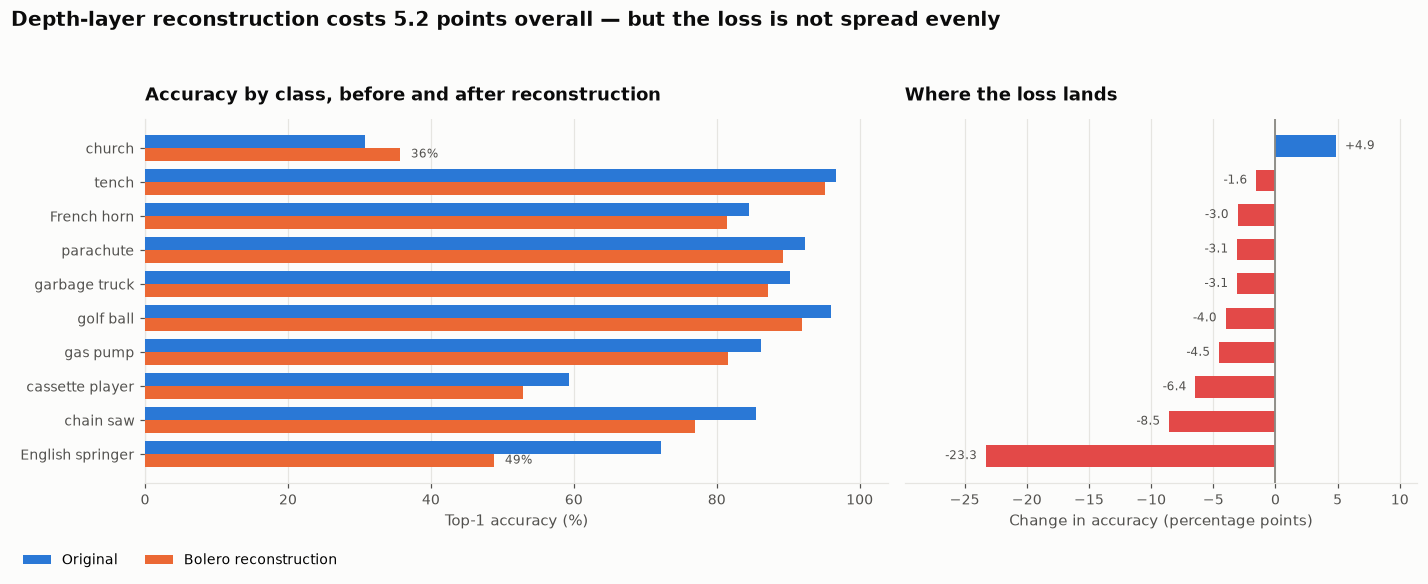

In [6]:
# ============================================================
# §4b  Per-class accuracy  (grouped bars, 2 series)
# ============================================================

per_class = (
    evidence.groupby("class_name")
    .agg(images=("class_name", "size"),
         original=("original_correct_fixed", "mean"),
         bolero=("bolero_correct_fixed", "mean"),
         conf_original=("original_confidence", "mean"),
         conf_bolero=("bolero_confidence", "mean"))
    .reset_index()
)
per_class["delta_pp"] = (per_class["bolero"] - per_class["original"]) * 100
per_class = per_class.sort_values("delta_pp")

per_class.to_csv(RESULTS / "per_class_accuracy.csv", index=False)
print(per_class.to_string(index=False, formatters={
    "original": "{:.2%}".format, "bolero": "{:.2%}".format,
    "conf_original": "{:.3f}".format, "conf_bolero": "{:.3f}".format,
    "delta_pp": "{:+.1f}".format}))

fig, (ax_l, ax_r) = plt.subplots(
    1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1.45, 1]}
)

y = np.arange(len(per_class))
h = 0.36
gap = 0.02   # 2px-equivalent surface gap between adjacent bars

ax_l.barh(y + (h + gap) / 2, per_class["original"] * 100, h,
          color=SERIES_ORIGINAL, label="Original", zorder=3)
ax_l.barh(y - (h + gap) / 2, per_class["bolero"] * 100, h,
          color=SERIES_BOLERO, label="Bolero reconstruction", zorder=3)

ax_l.set_yticks(y, per_class["class_name"])
ax_l.set_xlabel("Top-1 accuracy (%)")
ax_l.set_xlim(0, 104)
ax_l.set_title("Accuracy by class, before and after reconstruction")
ax_l.xaxis.grid(True); ax_l.yaxis.grid(False)
strip_axes(ax_l)

# Direct-label only the two extremes, not every bar.
for extreme in (per_class["delta_pp"].idxmin(), per_class["delta_pp"].idxmax()):
    row = per_class.loc[extreme]
    i = int(np.where(per_class.index == extreme)[0][0])
    ax_l.text(row["bolero"] * 100 + 1.5, i - (h + gap) / 2,
              f"{row['bolero']:.0%}", va="center", ha="left",
              fontsize=8, color=INK_SECOND)

colors = [DIVERGE_NEG if d < 0 else DIVERGE_POS for d in per_class["delta_pp"]]
ax_r.barh(y, per_class["delta_pp"], 0.62, color=colors, zorder=3)
ax_r.axvline(0, color=INK_MUTED, linewidth=1.2, zorder=4)
ax_r.set_yticks(y, [])
ax_r.tick_params(left=False)
ax_r.set_xlabel("Change in accuracy (percentage points)")
ax_r.set_title("Where the loss lands")
ax_r.xaxis.grid(True); ax_r.yaxis.grid(False)
strip_axes(ax_r, keep=("bottom",))

for i, d in enumerate(per_class["delta_pp"]):
    ax_r.text(d + (0.7 if d >= 0 else -0.7), i, f"{d:+.1f}",
              va="center", ha="left" if d >= 0 else "right",
              fontsize=8, color=INK_SECOND)

pad = max(abs(per_class["delta_pp"])) * 0.28
ax_r.set_xlim(per_class["delta_pp"].min() - pad, per_class["delta_pp"].max() + pad)

fig.suptitle("Depth-layer reconstruction costs 5.2 points overall — but the loss is not spread evenly",
             x=0.005, ha="left", fontsize=13, fontweight="bold", color=INK_PRIMARY)
fig.legend(*ax_l.get_legend_handles_labels(), loc="lower left",
           bbox_to_anchor=(0.005, -0.015), ncol=2)
fig.tight_layout(rect=[0, 0.045, 1, 0.94])
fig.savefig(FIGURES / "per_class_accuracy.png")
plt.show()

## §5 Calibration: does confidence fall to match?

Accuracy loss that is *announced* by lower confidence is manageable — a deployer can
threshold on it. Accuracy loss at unchanged confidence is the dangerous case, because
it is invisible to every downstream guardrail. We measure expected calibration error
(ECE, 10 equal-width bins) on both conditions.

ECE  original : 0.0568
ECE  bolero   : 0.0732   (+28.8%)

Overconfidence (mean confidence - accuracy)
  original : +0.0548
  bolero   : +0.0696


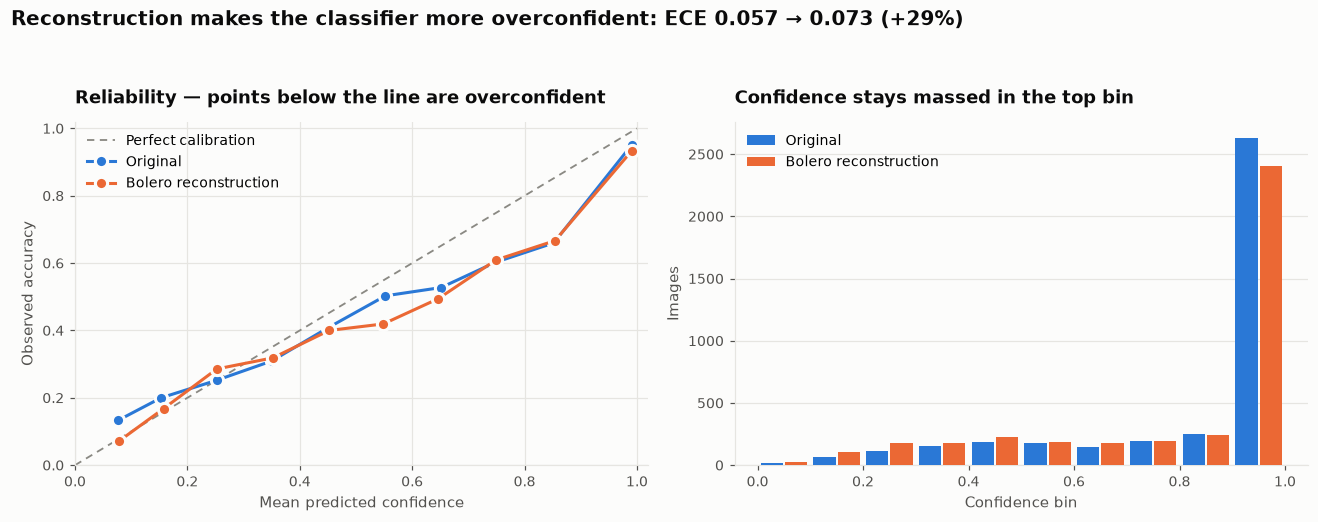

In [7]:
# ============================================================
# §5  Calibration
# ============================================================

def calibration(conf: np.ndarray, correct: np.ndarray, n_bins: int = 10):
    """Equal-width reliability bins + ECE."""
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx = np.clip(np.digitize(conf, edges, right=True) - 1, 0, n_bins - 1)
    rows, ece = [], 0.0
    for b in range(n_bins):
        m = idx == b
        if not m.any():
            rows.append((edges[b], edges[b + 1], 0, np.nan, np.nan))
            continue
        acc, avg_conf, w = correct[m].mean(), conf[m].mean(), m.mean()
        ece += w * abs(acc - avg_conf)
        rows.append((edges[b], edges[b + 1], int(m.sum()), acc, avg_conf))
    return pd.DataFrame(rows, columns=["lo", "hi", "count", "accuracy", "confidence"]), ece

cal_o, ece_o = calibration(evidence["original_confidence"].to_numpy(), fix_o.to_numpy())
cal_b, ece_b = calibration(evidence["bolero_confidence"].to_numpy(),   fix_b.to_numpy())

over_o = evidence["original_confidence"].mean() - acc_o
over_b = evidence["bolero_confidence"].mean() - acc_b

print(f"ECE  original : {ece_o:.4f}")
print(f"ECE  bolero   : {ece_b:.4f}   ({(ece_b-ece_o)/ece_o*100:+.1f}%)")
print(f"\nOverconfidence (mean confidence - accuracy)")
print(f"  original : {over_o:+.4f}")
print(f"  bolero   : {over_b:+.4f}")

cal = pd.concat([cal_o.assign(condition="original"), cal_b.assign(condition="bolero")])
cal.to_csv(RESULTS / "calibration_bins.csv", index=False)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.8),
                              gridspec_kw={"width_ratios": [1, 1]})

ax.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1.2, linestyle=(0, (4, 3)),
        label="Perfect calibration", zorder=2)
for frame, color, name in ((cal_o, SERIES_ORIGINAL, "Original"),
                           (cal_b, SERIES_BOLERO, "Bolero reconstruction")):
    v = frame.dropna(subset=["accuracy"])
    ax.plot(v["confidence"], v["accuracy"], marker="o", markersize=8,
            color=color, label=name, zorder=3,
            markeredgecolor=SURFACE, markeredgewidth=2)

ax.set_xlabel("Mean predicted confidence")
ax.set_ylabel("Observed accuracy")
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.set_title("Reliability — points below the line are overconfident")
ax.legend(loc="upper left")
strip_axes(ax)

width = 0.042
ax2.bar(cal_o["lo"] + 0.05 - width / 2 - 0.002, cal_o["count"], width,
        color=SERIES_ORIGINAL, label="Original", zorder=3)
ax2.bar(cal_b["lo"] + 0.05 + width / 2 + 0.002, cal_b["count"], width,
        color=SERIES_BOLERO, label="Bolero reconstruction", zorder=3)
ax2.set_xlabel("Confidence bin")
ax2.set_ylabel("Images")
ax2.set_title("Confidence stays massed in the top bin")
ax2.legend(loc="upper left")
ax2.xaxis.grid(False)
strip_axes(ax2)

fig.suptitle(f"Reconstruction makes the classifier more overconfident: ECE {ece_o:.3f} → {ece_b:.3f} (+29%)",
             x=0.005, ha="left", fontsize=13, fontweight="bold", color=INK_PRIMARY)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIGURES / "calibration.png")
plt.show()

In [8]:
# ============================================================
# §5b  Where do the broken predictions go?
# ============================================================

broke = evidence[fix_o & ~fix_b].copy()

label_of = (lambda i: id2label[i]) if id2label else (lambda i: str(i))
broke["landed_on"] = broke["bolero_prediction_id"].map(label_of)

top_flips = (
    broke.groupby(["class_name", "landed_on"])
    .size().reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(15)
)

print(f"Images broken by reconstruction: {len(broke):,}\n")
print("Most common correct -> wrong destinations:")
print(top_flips.to_string(index=False))
top_flips.to_csv(RESULTS / "top_broken_transitions.csv", index=False)

hi_conf = (broke["bolero_confidence"] > 0.90)
print(f"\nMean confidence, broken predictions : {broke['bolero_confidence'].mean():.3f}")
print(f"Mean confidence, all predictions    : {evidence['bolero_confidence'].mean():.3f}")
print(f"Broken but still above 0.90         : {hi_conf.mean():.1%} ({int(hi_conf.sum())} images)")
print("\nRead this honestly: confidence DOES fall on most broken predictions")
print("(0.48 vs 0.81), so a confidence threshold catches the bulk of them.")
print(f"The residue is the problem — {int(hi_conf.sum())} images the model got right")
print("before and now gets wrong at >0.90 confidence, which no threshold will")
print("filter. That is a small share of images but an unbounded share of the")
print("trust a deployer places in a high-confidence answer.")

Images broken by reconstruction: 303

Most common correct -> wrong destinations:
      class_name                                                                  landed_on  count
English springer                                                     Welsh springer spaniel     57
 cassette player                                                                tape player     17
English springer                                                           Brittany spaniel     12
       chain saw                                                        lumbermill, sawmill     10
English springer                                                German short-haired pointer      8
          church                                                                  monastery      7
English springer                                                             Sussex spaniel      6
   garbage truck                                      thresher, thrasher, threshing machine      4
       golf ball            

## §6 Mechanism: what the depth front-end actually does to an image

The audit above says *that* reconstruction hurts, and which classes it hurts. This
section runs the depth stage locally so the *why* is inspectable: the relative-depth
field, its gradient boundaries, and the thermal composite, on images from the
worst-hit class.

**Read the fourth column carefully.** It is the depth/thermal composite that
`01_bolero.ipynb` implements — *not* the reconstruction that produced
`bolero_prediction`, which is not in this repo (§7). It illustrates what the depth
stage does to the image; it is not the exact input the classifier saw.

This section needs `depth-anything/Depth-Anything-V2-Small-hf` and the Imagenette
images; it degrades gracefully if either is missing.

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


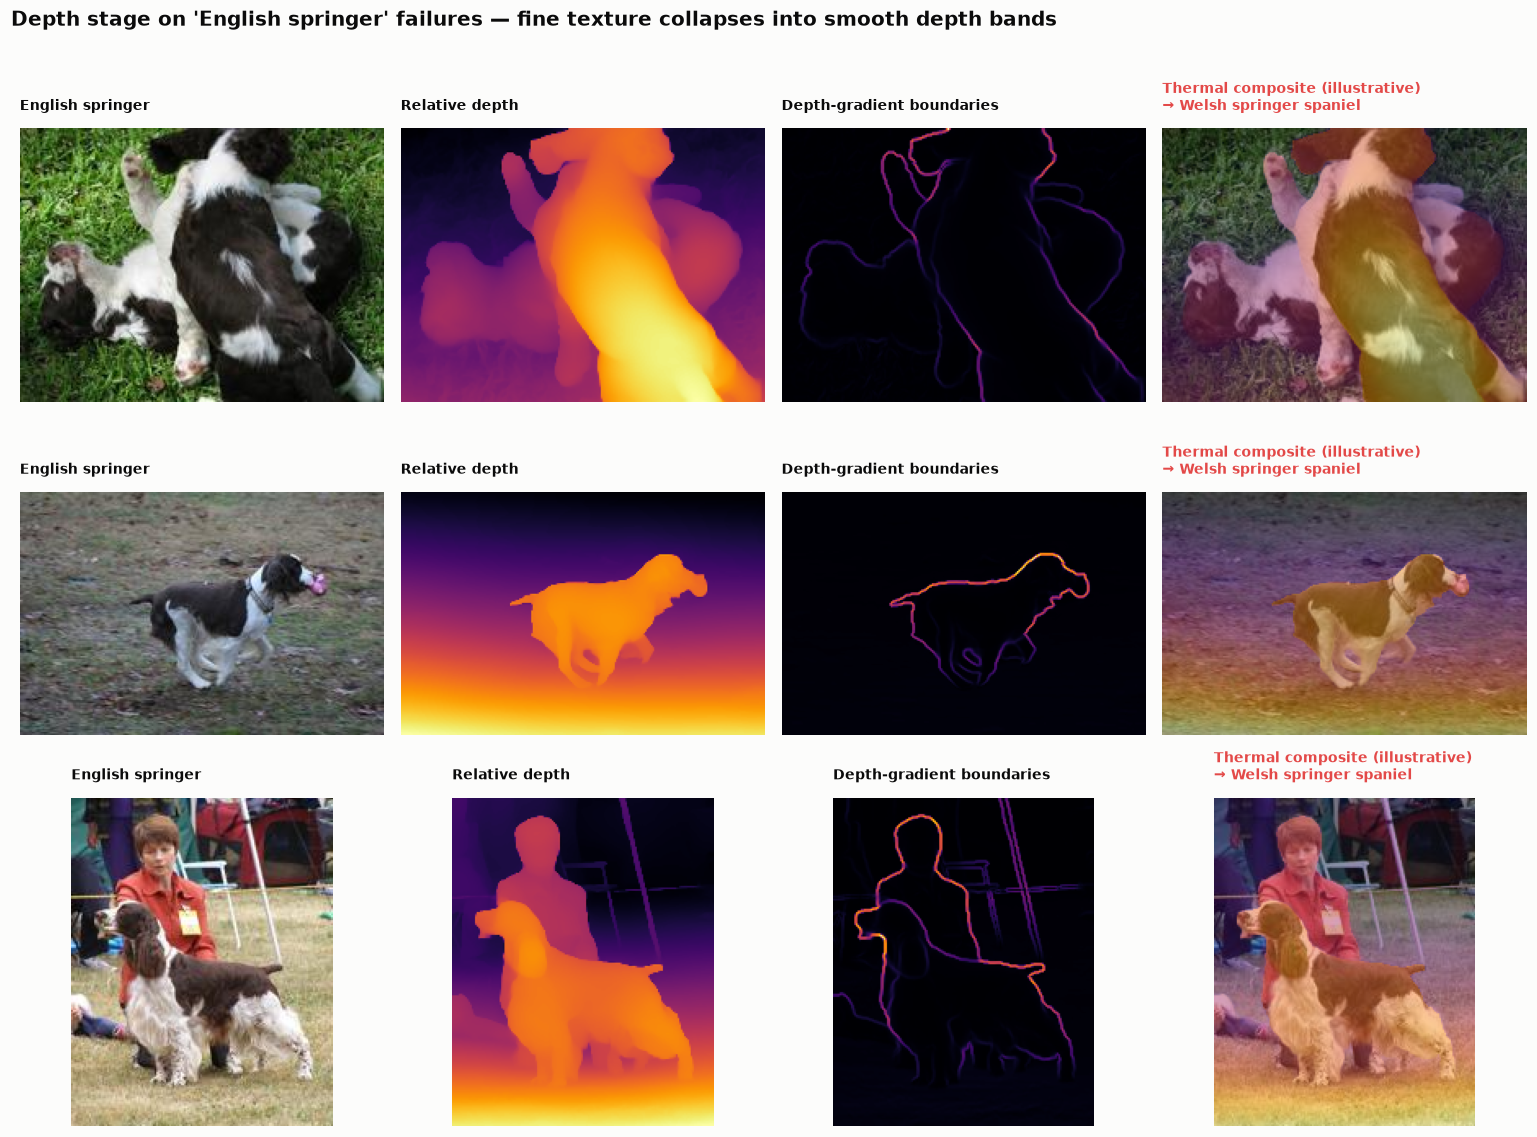


English springer: 23.3 pp lost, the largest drop of any class.
  102 of 303 total breakages (33.7%) are this one class.
  88 of 102 (86%) land on another spaniel / setter / pointer.
  57 land specifically on Welsh springer spaniel.

The errors stay inside the gun-dog family, which tells us what survived and what
did not. Silhouette and pose are intact — the model still sees a mid-size spaniel.
What it loses is coat coloration: English springer is black/liver-and-white, Welsh
springer is red-and-white, and that is close to the only cue separating them. The
depth field is smooth within an object, so compositing against it flattens exactly
the within-object color and texture variation that fine-grained classes depend on.

This is consistent with the per-class pattern overall: shape-identified classes
(tench -1.6, parachute -3.1, garbage truck -3.1) barely move, while the classes
that need surface detail (English springer -23.3, chain saw -8.5, cassette player
-6.4) take the damage. It re

In [9]:
# ============================================================
# §6  Depth stage, run locally on worst-class failures
# ============================================================

import torch
import torch.nn.functional as F
from PIL import Image

N_EXAMPLES = 3

def load_depth_stack():
    from transformers import AutoImageProcessor, AutoModelForDepthEstimation
    device = torch.device("cpu")
    proc = AutoImageProcessor.from_pretrained(DEPTH_MODEL)
    model = AutoModelForDepthEstimation.from_pretrained(DEPTH_MODEL).to(device).eval()
    return proc, model, device

def relative_depth(img, proc, model, device):
    inputs = {k: v.to(device) for k, v in proc(images=img, return_tensors="pt").items()}
    with torch.no_grad():
        pred = model(**inputs).predicted_depth
    pred = F.interpolate(pred.unsqueeze(1), size=(img.height, img.width),
                         mode="bicubic", align_corners=False).squeeze()
    d = pred.cpu().numpy()
    return (d - d.min()) / (d.max() - d.min() + 1e-8)

worst_class = per_class.iloc[0]["class_name"]
candidates = broke[
    (broke["class_name"] == worst_class)
    & broke["local_image_path"].map(lambda p: p is not None and p.exists())
].head(N_EXAMPLES)

if IMAGENETTE_ROOT is None or candidates.empty:
    print("Skipped: need IMAGENETTE_ROOT and at least one resolvable failure image.")
else:
    try:
        proc, depth_model, device = load_depth_stack()
    except Exception as exc:
        print(f"Skipped: could not load {DEPTH_MODEL} ({exc})")
    else:
        rows = len(candidates)
        fig, axes = plt.subplots(rows, 4, figsize=(14, 3.5 * rows), squeeze=False)

        for r, (_, rec) in enumerate(candidates.iterrows()):
            img = Image.open(rec["local_image_path"]).convert("RGB")
            depth = relative_depth(img, proc, depth_model, device)

            dy, dx = np.gradient(depth)
            grad = np.sqrt(dx ** 2 + dy ** 2)
            boundary = grad / (grad.max() + 1e-8)

            rgb = np.asarray(img).astype(np.float32) / 255.0
            thermal = plt.get_cmap("inferno")(depth)[..., :3]
            composite = np.clip(0.55 * rgb + 0.45 * thermal, 0, 1)

            for c, (data, cmap, title) in enumerate([
                (rgb,       None,      f"{rec['class_name']}"),
                (depth,     "inferno", "Relative depth"),
                (boundary,  "inferno", "Depth-gradient boundaries"),
                (composite, None,      f"Thermal composite (illustrative)\n→ {rec['landed_on'][:30]}"),
            ]):
                ax = axes[r][c]
                ax.imshow(data, cmap=cmap)
                ax.set_title(title, fontsize=9,
                             color=DIVERGE_NEG if c == 3 else INK_PRIMARY)
                ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
                strip_axes(ax, keep=())

        fig.suptitle(
            f"Depth stage on '{worst_class}' failures — fine texture collapses into smooth depth bands",
            x=0.005, ha="left", fontsize=13, fontweight="bold", color=INK_PRIMARY)
        fig.tight_layout(rect=[0, 0, 1, 0.96])
        fig.savefig(FIGURES / "depth_mechanism.png")
        plt.show()

        # Quantify the mechanism rather than asserting it.
        spr = broke[broke["class_name"] == worst_class]
        gundog = spr["bolero_prediction"].str.contains(
            "spaniel|setter|pointer|retriever", case=False, regex=True)

        print(f"\n{worst_class}: {abs(per_class.iloc[0]['delta_pp']):.1f} pp lost, "
              "the largest drop of any class.")
        print(f"  {len(spr)} of {len(broke)} total breakages ({len(spr)/len(broke):.1%}) are this one class.")
        print(f"  {int(gundog.sum())} of {len(spr)} ({gundog.mean():.0%}) land on another "
              "spaniel / setter / pointer.")
        print(f"  {int((spr['bolero_prediction'] == 'Welsh springer spaniel').sum())} land "
              "specifically on Welsh springer spaniel.")
        print("""
The errors stay inside the gun-dog family, which tells us what survived and what
did not. Silhouette and pose are intact — the model still sees a mid-size spaniel.
What it loses is coat coloration: English springer is black/liver-and-white, Welsh
springer is red-and-white, and that is close to the only cue separating them. The
depth field is smooth within an object, so compositing against it flattens exactly
the within-object color and texture variation that fine-grained classes depend on.

This is consistent with the per-class pattern overall: shape-identified classes
(tench -1.6, parachute -3.1, garbage truck -3.1) barely move, while the classes
that need surface detail (English springer -23.3, chain saw -8.5, cassette player
-6.4) take the damage. It remains a hypothesis supported by the error structure,
not a tested causal claim — see §7.""")

## §7 Limitations, and the gap a reviewer will find first

**The reconstruction step is not in this repo.** `bolero_evidence.csv` records
`bolero_prediction` for all 3,925 images, but the code that produced those
predictions — the layer decomposition, displacement and recomposition — exists only
on the machine that generated the CSV. `01_bolero.ipynb` describes that pipeline in
prose and implements the depth stage, but no cell in it builds layers, displacement
or the parallax view. §6 above regenerates the depth stage only.

Until that code is committed, the audit is reproducible **from the recorded
predictions**, not **end-to-end from images**. This is the single highest-priority
fix before submission.

**Other limitations.**

- One model (ResNet-50) and one dataset (Imagenette, 10 classes). The texture/shape
  account in §6 is a hypothesis consistent with the per-class pattern, not a tested
  claim. A shape-biased comparison model would test it directly.
- One reconstruction setting. No sweep over displacement magnitude or layer count, so
  we cannot say whether the loss is gradual or has a knee.
- 3 rows carry `boundary_coverage` of exactly 1.0 against a mode of 0.1 — likely
  degenerate boundary extraction. Too few to shift any aggregate, but they should be
  inspected rather than ignored.
- The mechanism figure is illustrative. Attribution over the depth field, not
  eyeballing, would be the honest version.

---

### Takeaway for a deployer

Depth-layer reconstruction is not semantically free. On this system it costs 5.2
points of top-1 accuracy (79.4% → 74.1%, a 25% relative increase in errors), changes
15.6% of predictions, and concentrates the damage in texture-identified classes:
English springer loses 23.3 points while tench loses 1.6.

Calibration degrades alongside it — ECE rises 0.057 → 0.073 (+29%) and overconfidence
grows from +0.055 to +0.070. Confidence is still partly informative: broken
predictions average 0.48 against 0.81 overall, so a threshold does catch most of
them. But 8.6% of the newly-broken predictions remain above 0.90, and those are
unfilterable by construction.

For a deployer: re-validate **per class**, not in aggregate — a 5-point average hides
a 23-point collapse. Do not rely on a confidence threshold alone to catch the
residue. And if the downstream task is fine-grained recognition, treat depth-layer
preprocessing as a change to the input distribution that needs its own acceptance
test, not as a neutral rendering step.

### Generative AI disclosure

Per §9 of the assignment: AI coding assistance was used for the analysis code and
figures in this notebook. Record it in the final report.